# Baseline vs. Attention-Entropy Regularization

This notebook compares a baseline Kepler block-size run with a run trained using normalized causal-attention entropy regularization. Update the configuration below to match the two `.npz` files produced by `kepler_cv_blocksize.py`.

The regularizer is active on the half-open step interval `[start_step, end_step)`. Thus, `start_step=1000, end_step=None` means **after step 1000**, while `start_step=0, end_step=1000` means **before step 1000**.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
RESULT_DIR = Path('./results/kepler_cv_blocksize')


## Experiment files

In [2]:
# Keep these values synchronized with kepler_cv_blocksize.py.
block_size = 100
num_trajectories = 10_000
noise_scale = 0.1
loss_mask = 'all'

# Entropy experiment settings. Positive coefficients penalize diffuse attention.
entropy_coefficient = 1e-3
entropy_start_step = 0          # inclusive; use 0 for regularization from the beginning
entropy_end_step = None         # exclusive; None means through the final training step

base_stem = (
    f'results_block_size_{block_size}_num_trajectories_{num_trajectories}'
    f'_noise_scale_{noise_scale}_loss_mask_{loss_mask}'
)
end_label = 'none' if entropy_end_step is None else str(entropy_end_step)
entropy_suffix = (
    f'_attention_entropy_reg_{entropy_coefficient}'
    f'_start_{entropy_start_step}_end_{end_label}'
)

baseline_path = RESULT_DIR / f'{base_stem}.npz'
entropy_path = RESULT_DIR / f'{base_stem}{entropy_suffix}.npz'

print('Baseline:', baseline_path)
print('Entropy: ', entropy_path)
assert baseline_path.exists(), f'Missing baseline result: {baseline_path}'
assert entropy_path.exists(), f'Missing entropy result: {entropy_path}'


Baseline: results/kepler_cv_blocksize/results_block_size_100_num_trajectories_10000_noise_scale_0.1_loss_mask_all.npz
Entropy:  results/kepler_cv_blocksize/results_block_size_100_num_trajectories_10000_noise_scale_0.1_loss_mask_all_attention_entropy_reg_0.001_start_0_end_none.npz


## Load and inspect results

In [3]:
def load_result(path):
    with np.load(path, allow_pickle=True) as loaded:
        result = {}
        for key in loaded.files:
            value = loaded[key]
            # Unwrap scalar object arrays while leaving numeric histories as arrays.
            result[key] = value.item() if value.shape == () else value
    return result

baseline = load_result(baseline_path)
entropy_run = load_result(entropy_path)

summary_keys = [
    'block_size', 'num_trajectories', 'noise_scale', 'loss_mask',
    'attention_entropy_reg', 'attention_entropy_reg_start_step',
    'attention_entropy_reg_end_step', 'final_test_loss'
]
pd.DataFrame({
    'baseline': {k: baseline.get(k, 'not recorded') for k in summary_keys},
    'entropy_regularized': {k: entropy_run.get(k, 'not recorded') for k in summary_keys},
})


,baseline,entropy_regularized
block_size,100,100
num_trajectories,20000,20000
noise_scale,0.1,0.1
loss_mask,all,all
attention_entropy_reg,not recorded,0.001
attention_entropy_reg_start_step,not recorded,0
attention_entropy_reg_end_step,not recorded,None
final_test_loss,0.001327,0.001243


## Training and test losses

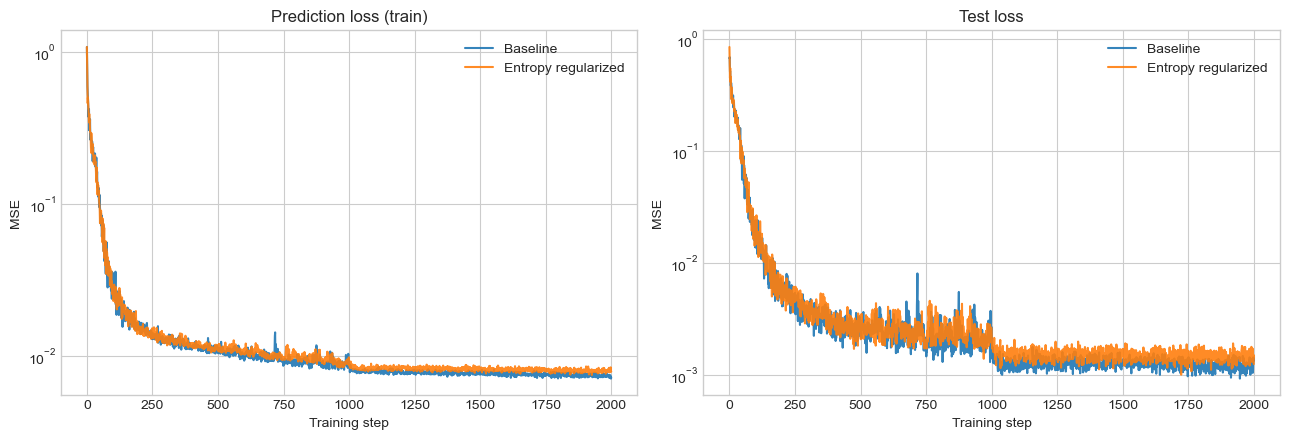

In [4]:
def prediction_history(result):
    # Old baseline files do not have prediction_losses; train_losses is equivalent
    # because their entropy coefficient was zero.
    return np.asarray(result.get('prediction_losses', result['train_losses']), dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for label, result, color in [
    ('Baseline', baseline, 'tab:blue'),
    ('Entropy regularized', entropy_run, 'tab:orange'),
]:
    axes[0].plot(prediction_history(result), label=label, color=color, alpha=0.9)
    axes[1].plot(np.asarray(result['test_losses'], dtype=float), label=label, color=color, alpha=0.9)

axes[0].set(title='Prediction loss (train)', xlabel='Training step', ylabel='MSE', yscale='log')
axes[1].set(title='Test loss', xlabel='Training step', ylabel='MSE', yscale='log')
for ax in axes:
    ax.legend()
plt.tight_layout()


## Attention entropy and active regularization interval

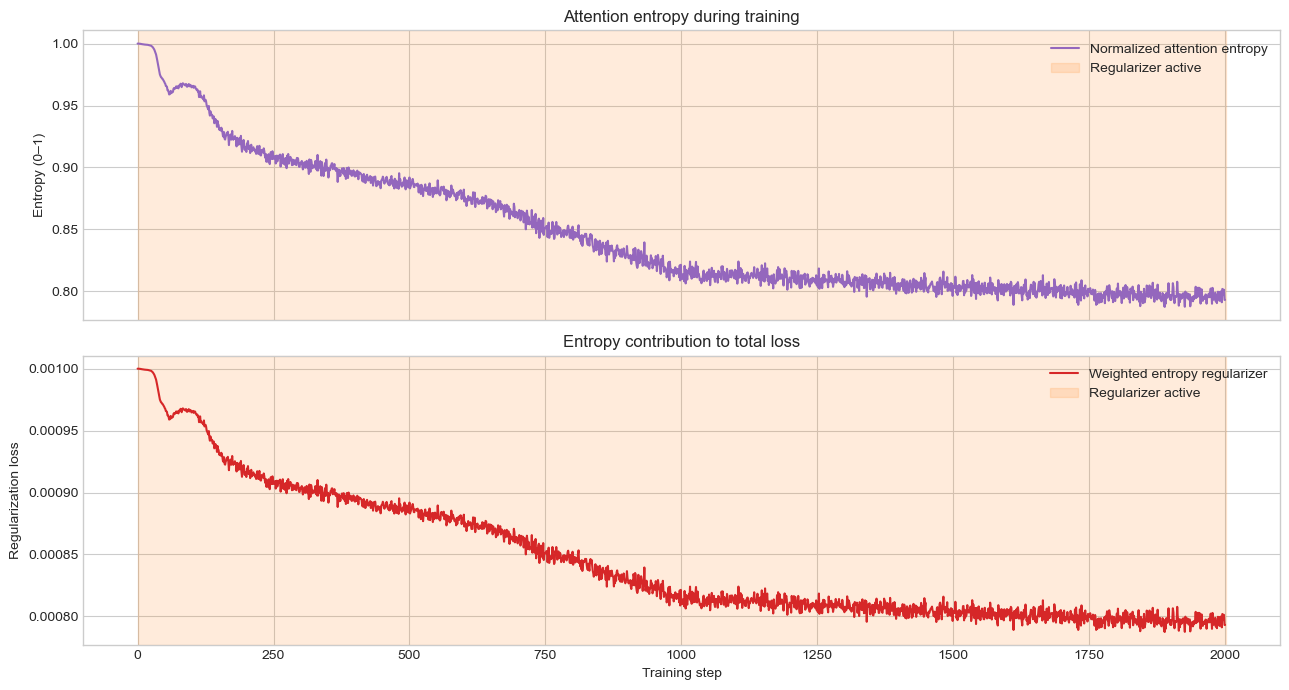

In [5]:
entropies = np.asarray(entropy_run['attention_entropies'], dtype=float)
reg_losses = np.asarray(entropy_run['attention_entropy_reg_losses'], dtype=float)
active = np.asarray(entropy_run['attention_entropy_reg_active'], dtype=bool)
steps = np.arange(len(entropies))

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(steps, entropies, color='tab:purple', label='Normalized attention entropy')
axes[0].set_ylabel('Entropy (0–1)')
axes[0].set_title('Attention entropy during training')
axes[1].plot(steps, reg_losses, color='tab:red', label='Weighted entropy regularizer')
axes[1].set(xlabel='Training step', ylabel='Regularization loss', title='Entropy contribution to total loss')

if active.any():
    active_steps = steps[active]
    for ax in axes:
        ax.axvspan(active_steps.min(), active_steps.max() + 1, color='tab:orange', alpha=0.15, label='Regularizer active')
for ax in axes:
    ax.legend()
plt.tight_layout()


## Periodic rollout error comparison

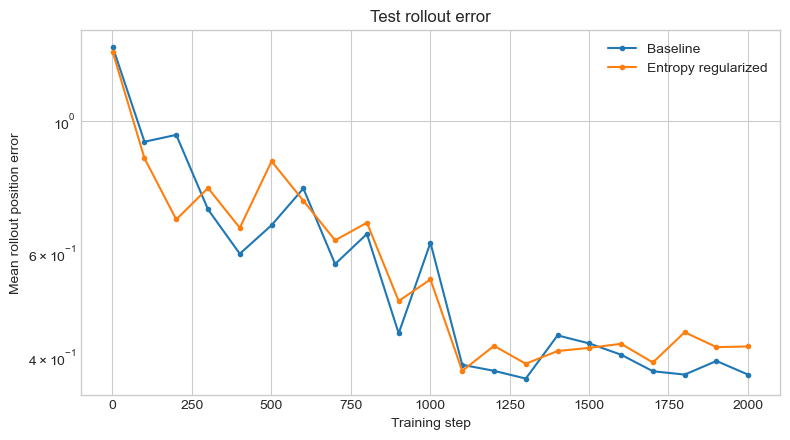

In [6]:
def evaluation_history(result, split='test'):
    steps = np.asarray(result['eval_steps'], dtype=int)
    evaluations = list(result['eval_results'])
    errors = np.asarray([
        evaluation[f'error_stats_{split}']['mean_error'] for evaluation in evaluations
    ], dtype=float)
    return steps, errors

fig, ax = plt.subplots(figsize=(8, 4.5))
for label, result, color in [
    ('Baseline', baseline, 'tab:blue'),
    ('Entropy regularized', entropy_run, 'tab:orange'),
]:
    eval_steps, errors = evaluation_history(result, 'test')
    ax.plot(eval_steps, errors, marker='o', markersize=3, label=label, color=color)
ax.set(xlabel='Training step', ylabel='Mean rollout position error', title='Test rollout error')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()


## Final linear-probe comparison

,baseline_mean_r2_last,entropy_mean_r2_last,difference
F_direction_x,0.949587,0.961824,0.012237
F_direction_y,0.936102,0.963179,0.027077
F_magnitude,0.588551,0.602144,0.013593
Fx,0.501696,0.489398,-0.012298
Fy,0.464625,0.553754,0.089129
inv_r,0.739303,0.769254,0.029950
inv_r_cubed,0.436192,0.430986,-0.005206
inv_r_squared,0.588557,0.602151,0.013594
r,0.801557,0.816431,0.014874
r_squared,0.768236,0.790934,0.022698


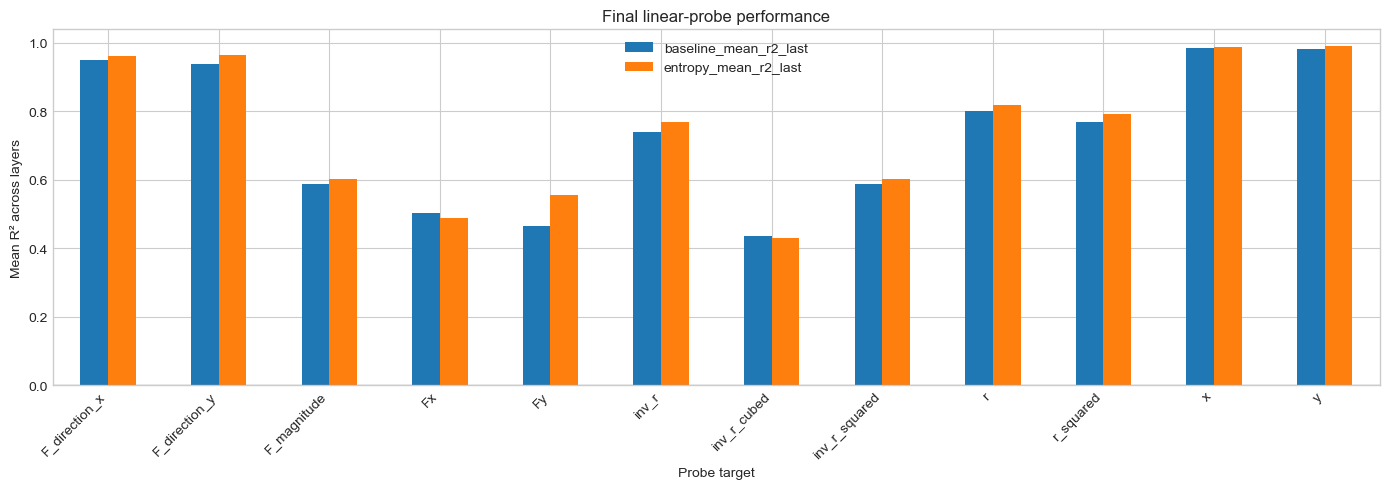

In [7]:
def final_probe_frame(result, probe_key='probe_results', score='r2_last'):
    final_eval = list(result['eval_results'])[-1]
    probes = final_eval.get(probe_key)
    if not probes:
        return pd.DataFrame()
    return pd.DataFrame({
        layer: {target: values[score] for target, values in targets.items()}
        for layer, targets in probes.items()
    })

baseline_probes = final_probe_frame(baseline)
entropy_probes = final_probe_frame(entropy_run)
probe_comparison = pd.DataFrame({
    'baseline_mean_r2_last': baseline_probes.mean(axis=1),
    'entropy_mean_r2_last': entropy_probes.mean(axis=1),
}).sort_index()
probe_comparison['difference'] = (
    probe_comparison['entropy_mean_r2_last'] - probe_comparison['baseline_mean_r2_last']
)

ax = probe_comparison[['baseline_mean_r2_last', 'entropy_mean_r2_last']].plot.bar(
    figsize=(14, 5), color=['tab:blue', 'tab:orange']
)
ax.set(xlabel='Probe target', ylabel='Mean R² across layers', title='Final linear-probe performance')
ax.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
probe_comparison


## Final numerical summary

In [8]:
def final_rollout_error(result, split='test'):
    return float(list(result['eval_results'])[-1][f'error_stats_{split}']['mean_error'])

summary = pd.DataFrame({
    'baseline': {
        'final prediction loss': prediction_history(baseline)[-1],
        'final test loss': np.asarray(baseline['test_losses'], dtype=float)[-1],
        'final test rollout error': final_rollout_error(baseline),
    },
    'entropy_regularized': {
        'final prediction loss': prediction_history(entropy_run)[-1],
        'final test loss': np.asarray(entropy_run['test_losses'], dtype=float)[-1],
        'final test rollout error': final_rollout_error(entropy_run),
        'final normalized attention entropy': entropies[-1],
    },
})
summary['relative_change'] = summary['entropy_regularized'] / summary['baseline'] - 1
summary


,baseline,entropy_regularized,relative_change
final prediction loss,0.007222,0.007916,0.096179
final test loss,0.001327,0.001243,-0.063728
final test rollout error,0.374242,0.417462,0.115487
final normalized attention entropy,NaN,0.793094,NaN


## Newtonian probe comparison across layers
The two lines show final-step $R^2_{last}$ for the baseline and attention-entropy-regularized runs.


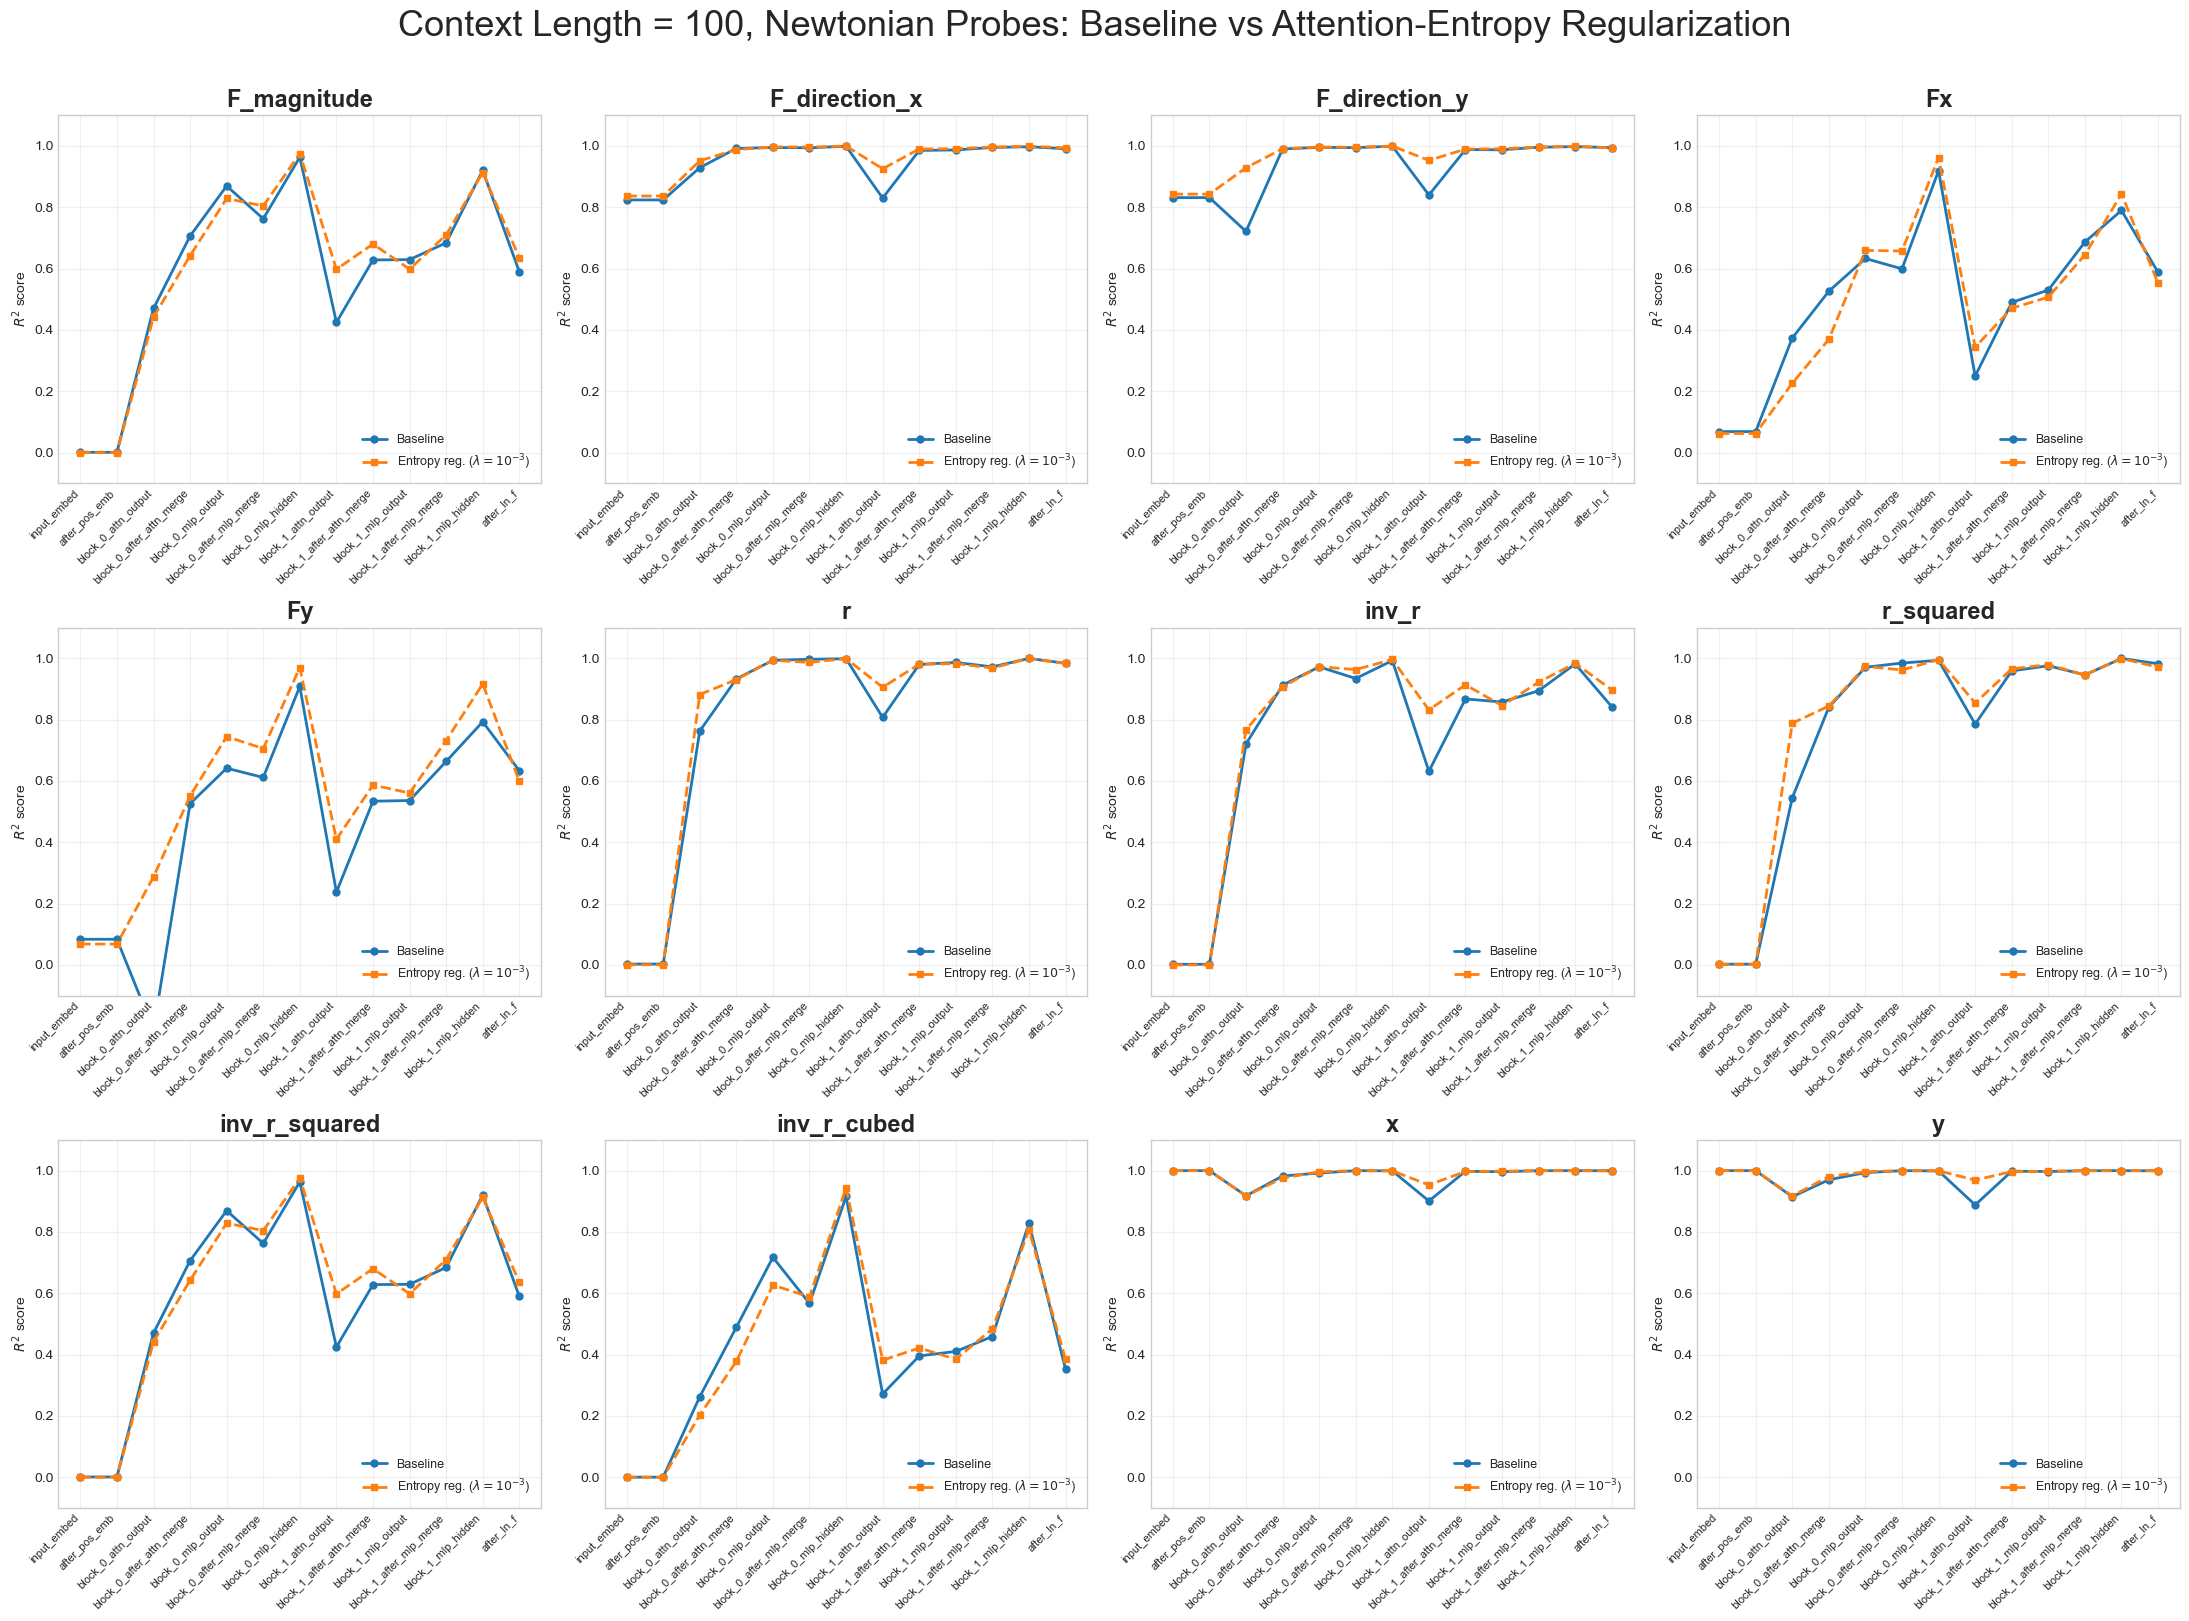

Saved to plots/force_probes_block_size_100_baseline_vs_attention_entropy.png


In [9]:
baseline_probes = list(baseline['eval_results'])[-1]['probe_results']
entropy_probes = list(entropy_run['eval_results'])[-1]['probe_results']

layer_order = ['input_embed', 'after_pos_emb']
for block_idx in range(2):
    layer_order.extend([
        f'block_{block_idx}_attn_output',
        f'block_{block_idx}_after_attn_merge',
        f'block_{block_idx}_mlp_output',
        f'block_{block_idx}_after_mlp_merge',
        f'block_{block_idx}_mlp_hidden',
    ])
layer_order.append('after_ln_f')
available_layers = [
    layer for layer in layer_order
    if layer in baseline_probes and layer in entropy_probes
]
target_variables = [
    'F_magnitude', 'F_direction_x', 'F_direction_y', 'Fx',
    'Fy', 'r', 'inv_r', 'r_squared', 'inv_r_squared',
    'inv_r_cubed', 'x', 'y',
]

fig, axes = plt.subplots(3, 4, figsize=(22, 16))
x_positions = np.arange(len(available_layers))
for ax, target in zip(axes.flat, target_variables):
    baseline_scores = [baseline_probes[layer][target]['r2_last'] for layer in available_layers]
    entropy_scores = [entropy_probes[layer][target]['r2_last'] for layer in available_layers]
    ax.plot(x_positions, baseline_scores, 'o-', lw=2, ms=5, label='Baseline')
    ax.plot(x_positions, entropy_scores, 's--', lw=2, ms=5,
            label=r'Entropy reg. ($\lambda=10^{-3}$)')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(available_layers, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel(r'$R^2$ score')
    ax.set_title(target, fontsize=17, fontweight='bold')
    ax.set_ylim(-0.1, 1.1)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='lower right')

fig.suptitle(
    'Context Length = 100, Newtonian Probes: Baseline vs Attention-Entropy Regularization',
    fontsize=26, y=1.01,
)
fig.tight_layout()
probe_comparison_path = Path('plots/force_probes_block_size_100_baseline_vs_attention_entropy.png')
probe_comparison_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(probe_comparison_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved to {probe_comparison_path}')


## Four-run entropy-coefficient sweep
Comparison of $\lambda \in \{0,10^{-3},10^{-2},10^{-1}\}$.


,attention_entropy_reg,final_prediction_loss,final_test_loss,final_test_rollout_error,final_attention_entropy
0,0.000,0.007222,0.001327,0.374242,NaN
1,0.001,0.007916,0.001243,0.417462,0.793094
2,0.010,0.009915,0.001765,0.427405,0.061613
3,0.100,0.012064,0.002109,0.929849,0.010537


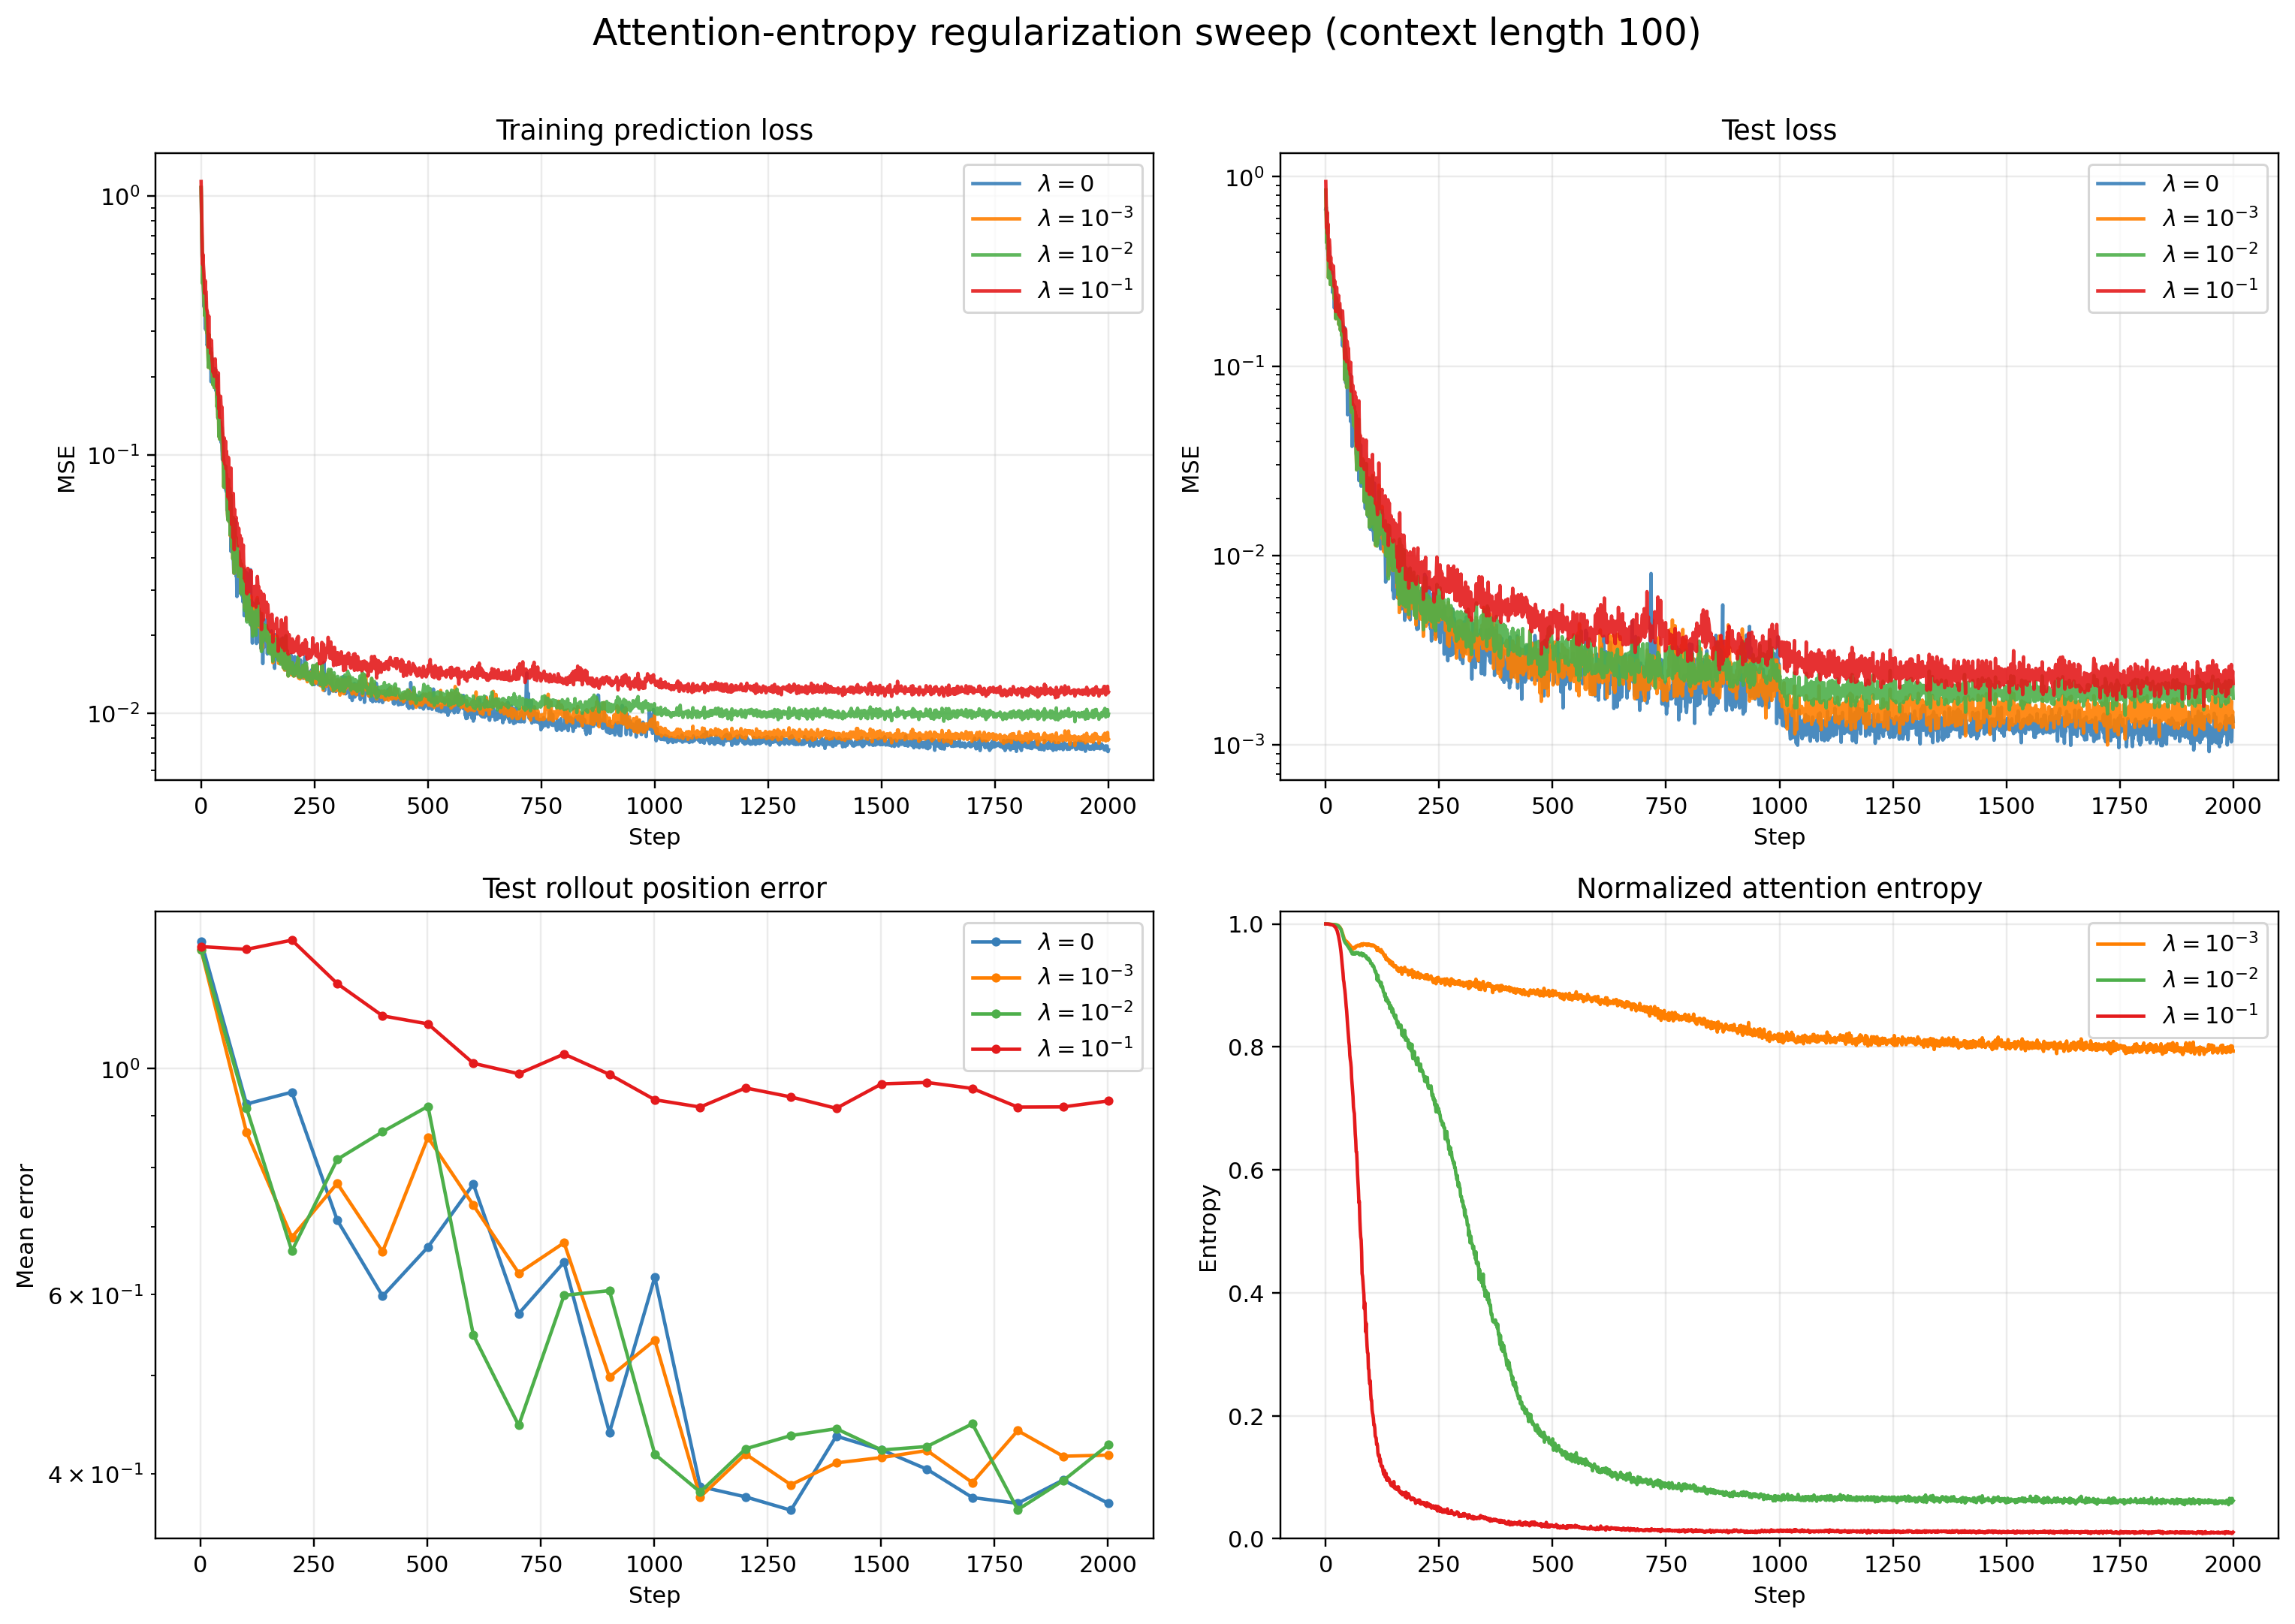

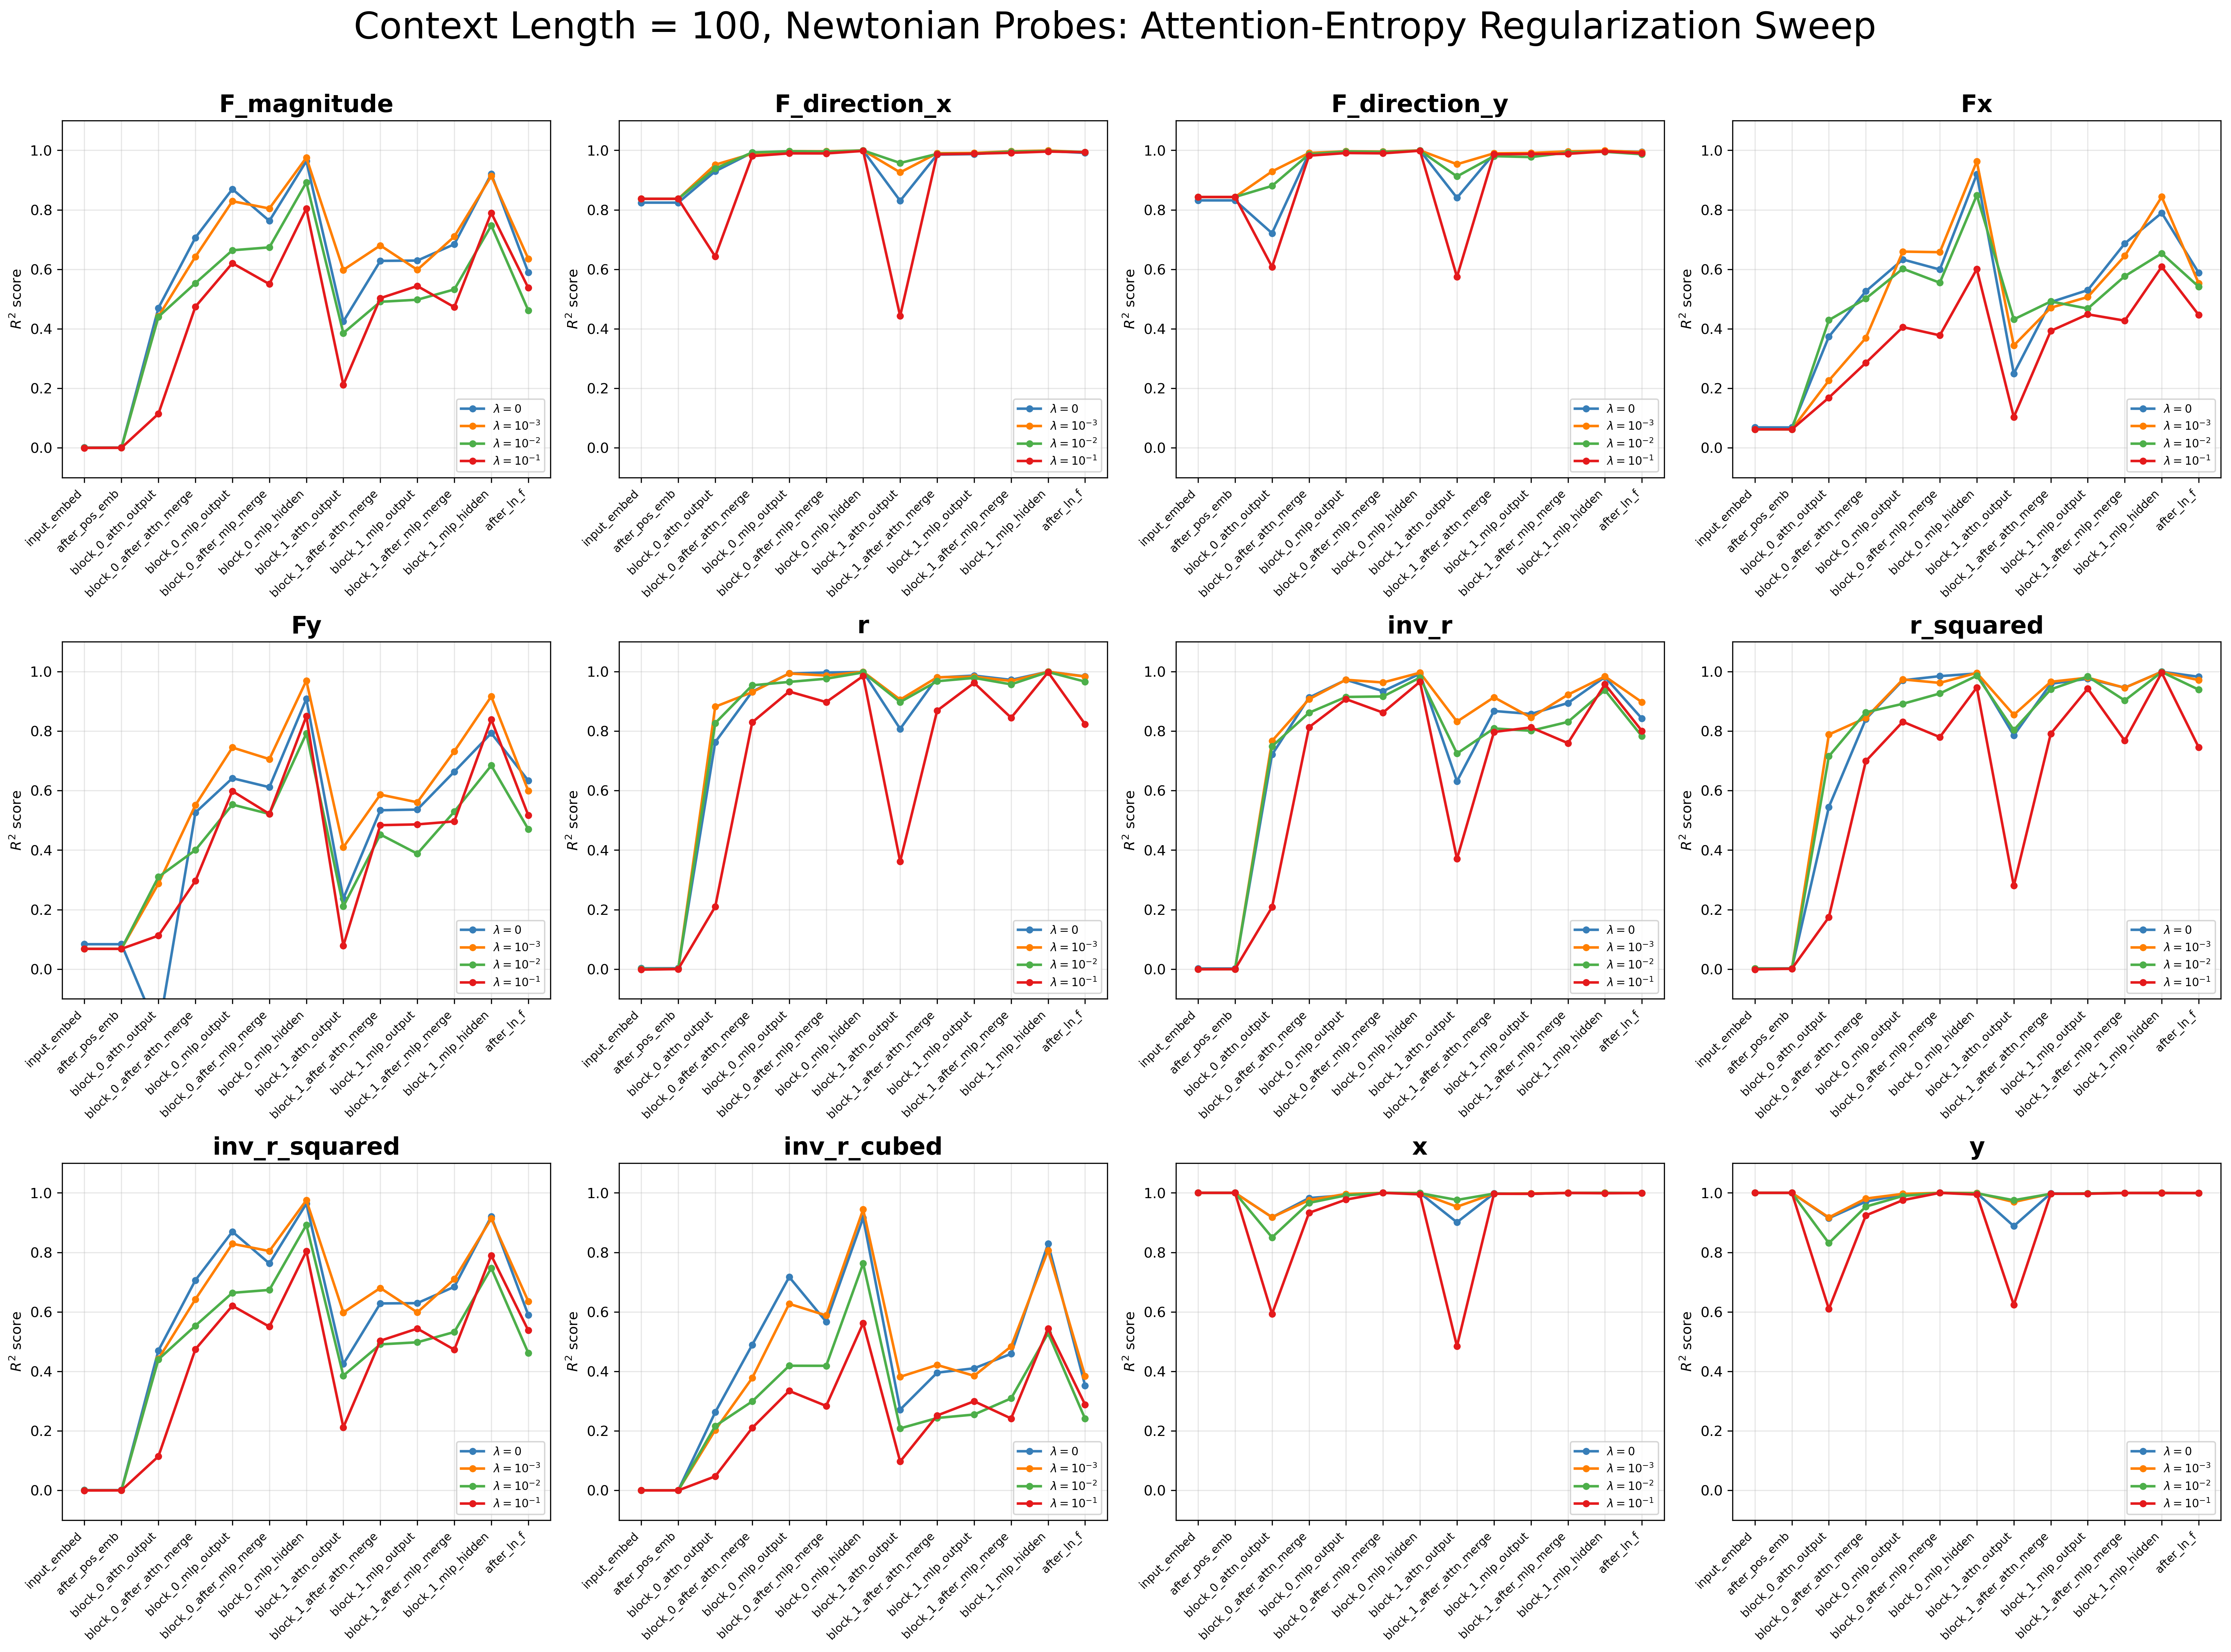

In [10]:
from IPython.display import display, Image

four_run_summary = pd.read_csv(
    'results/kepler_cv_blocksize/attention_entropy_four_run_summary.csv'
)
display(four_run_summary)
display(Image(filename='plots/attention_entropy_four_run_comparison.png'))
display(Image(filename='plots/force_probes_block_size_100_four_entropy_runs.png'))


## 20,000-step comparison: baseline vs $\lambda=10^{-3}$


,run,final_prediction_loss,final_test_loss,final_test_rollout_error,final_attention_entropy
0,Baseline,0.002284,0.000529,0.126097,NaN
1,Entropy reg. ($\lambda=10^{-3}$),0.002432,0.000342,0.081198,0.759231


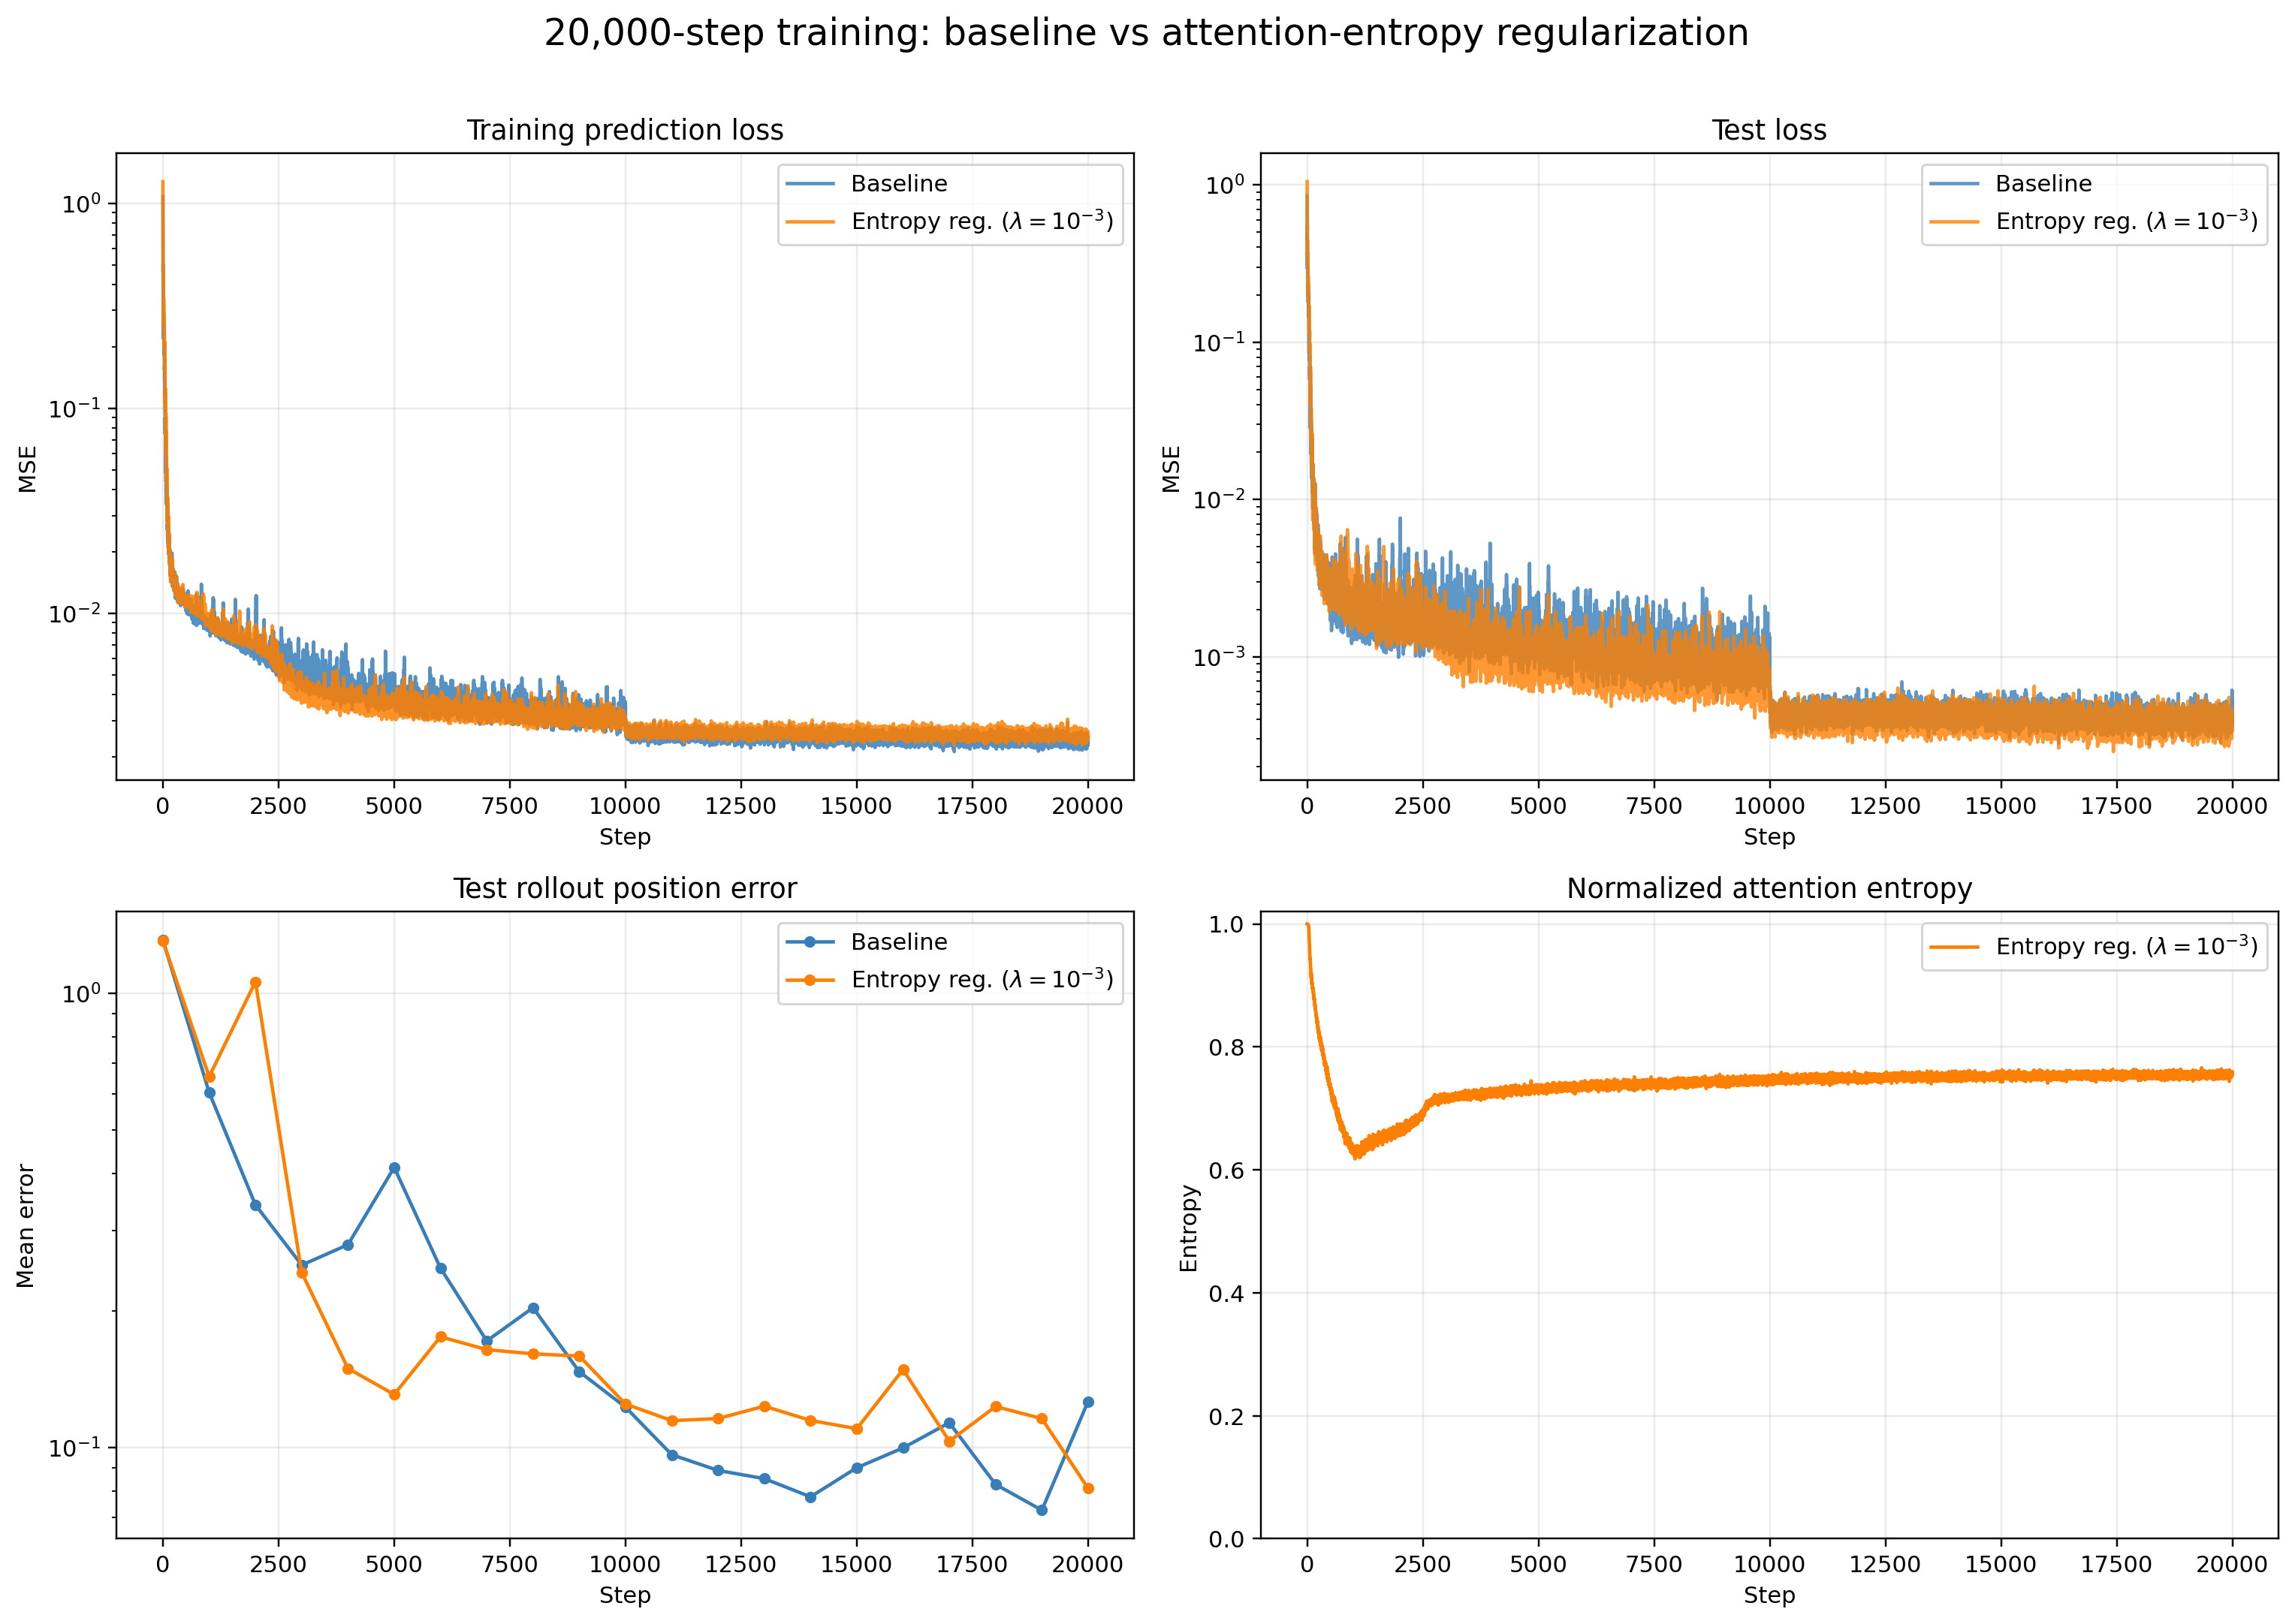

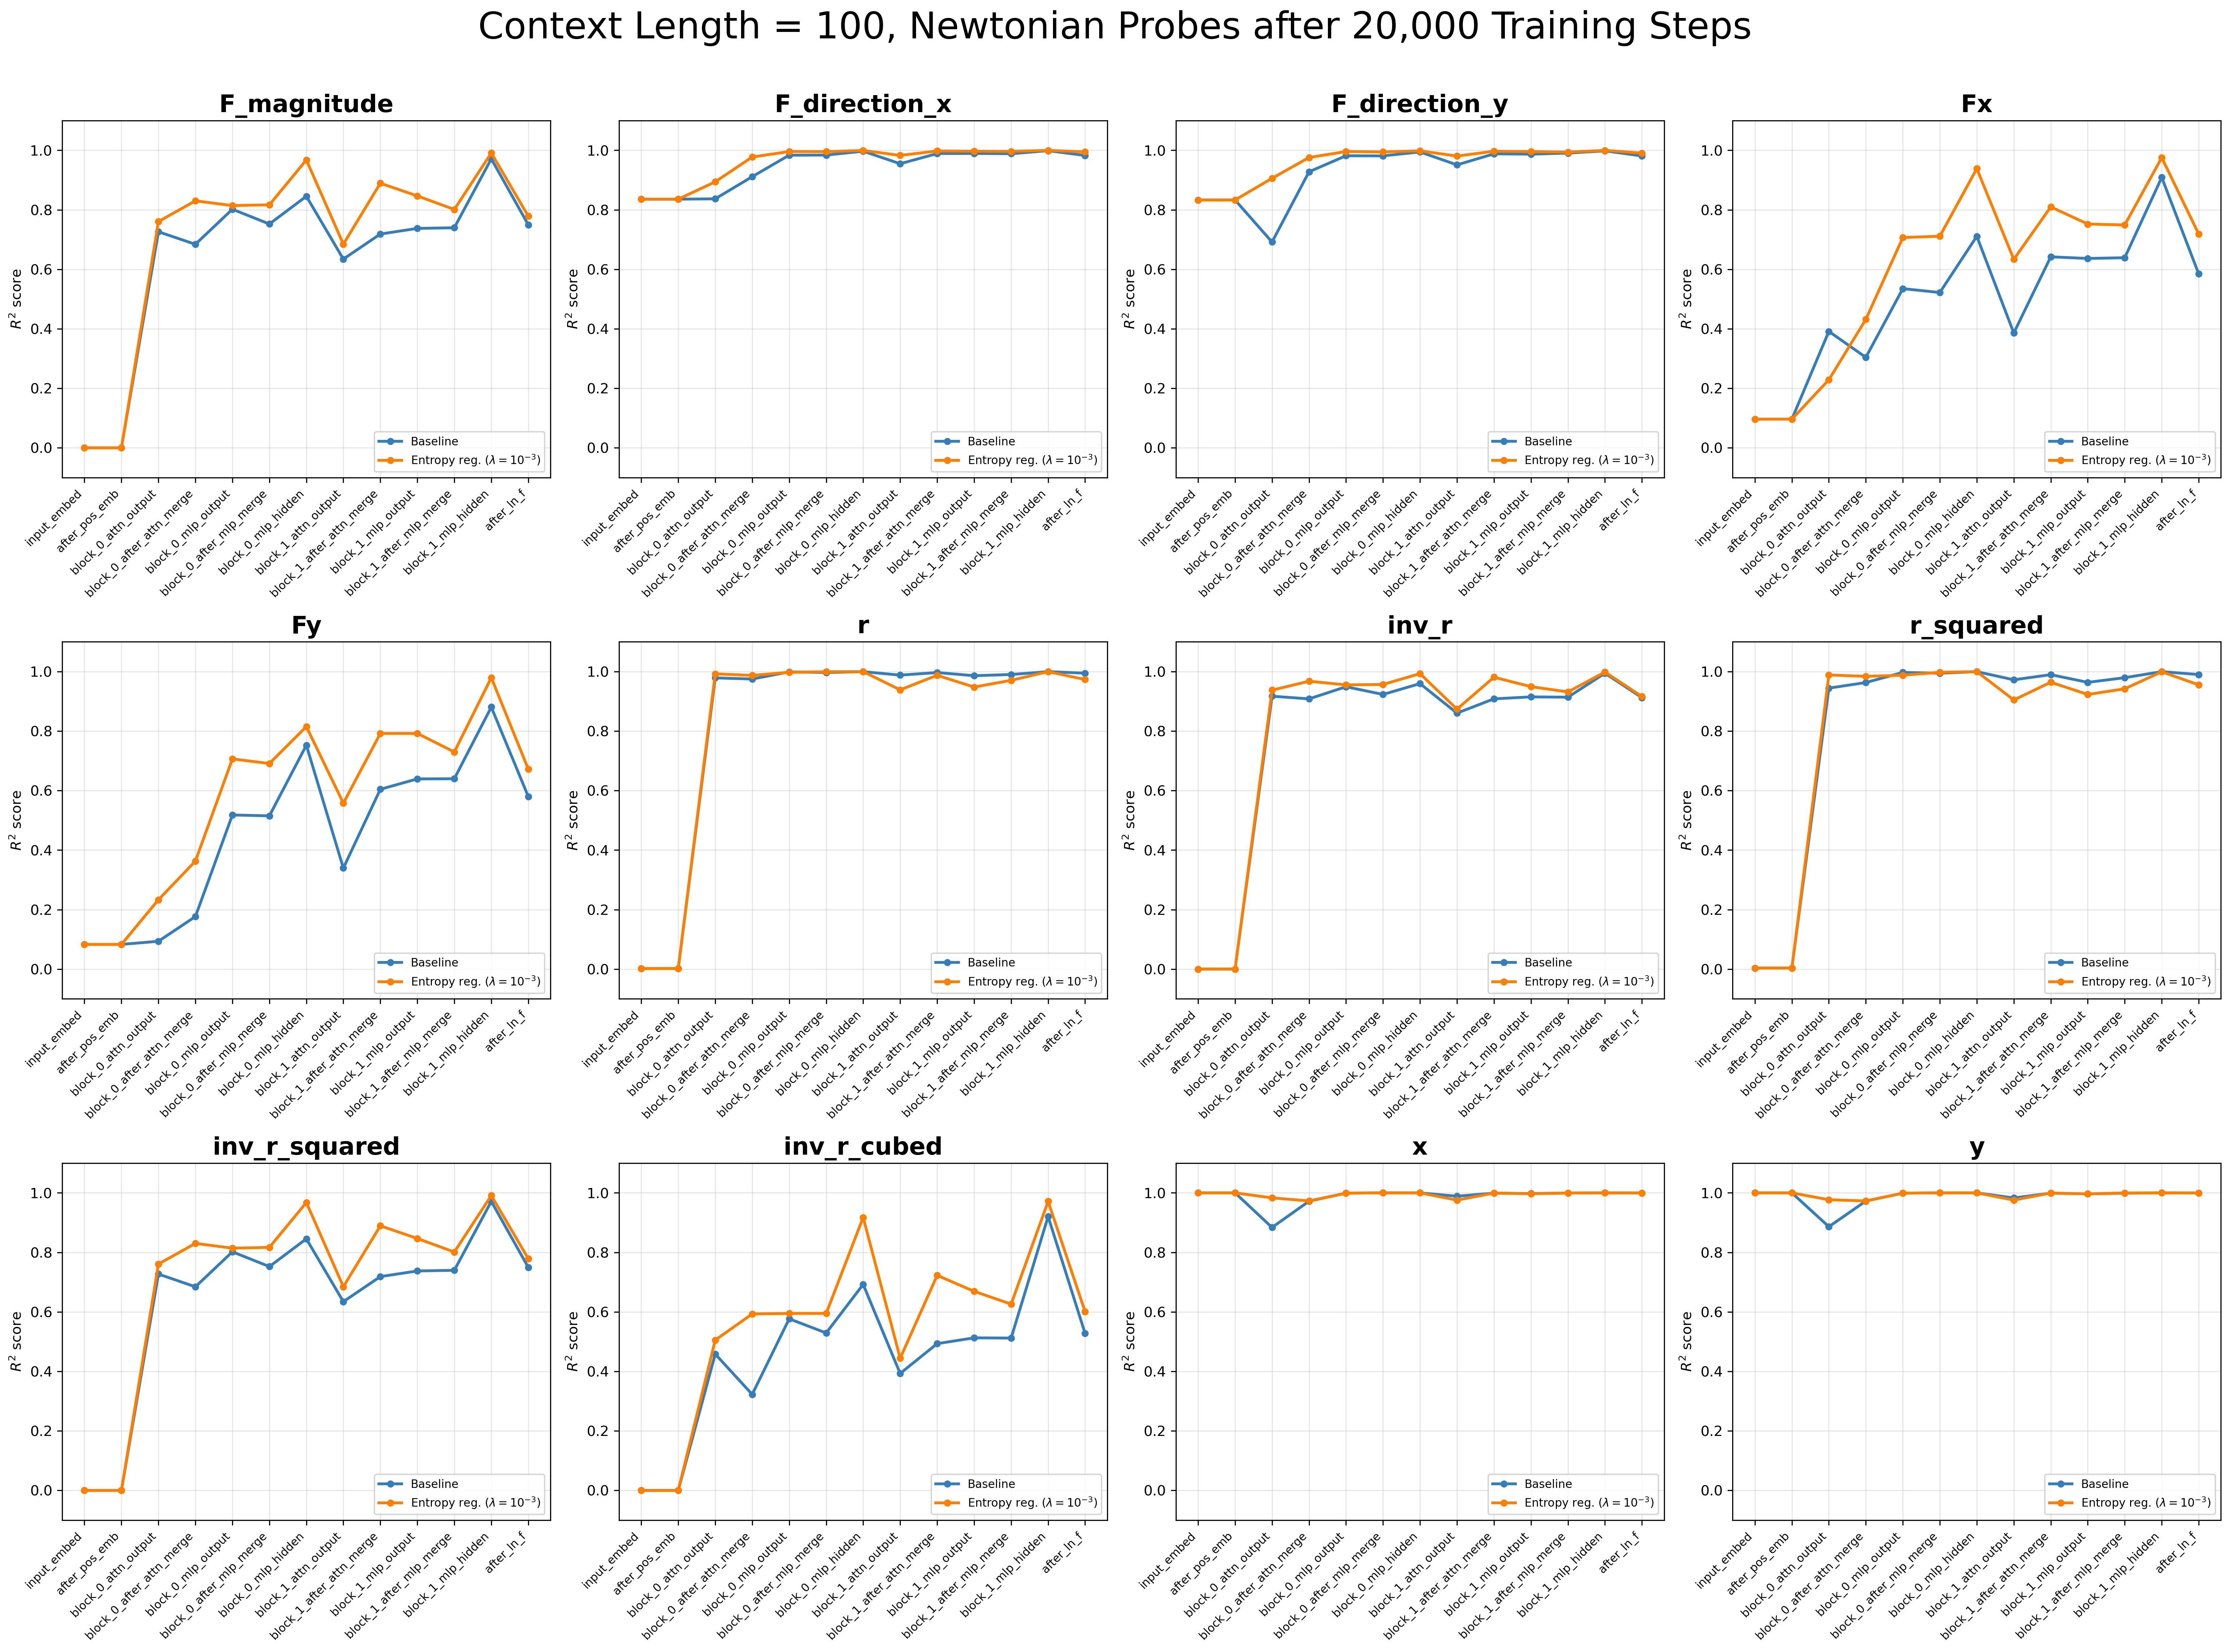

In [11]:
from IPython.display import display, Image
comparison_20000 = pd.read_csv(
    'results/kepler_cv_blocksize/attention_entropy_20000_step_comparison.csv'
)
display(comparison_20000)
display(Image(filename='plots/attention_entropy_baseline_vs_1e-3_20000_steps.png'))
display(Image(filename='plots/force_probes_block_size_100_baseline_vs_1e-3_20000_steps.png'))
